In [1]:
!pip install gymnasium stable-baselines3
!pip install shimmy

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [2]:
!pip install xlsxwriter

Defaulting to user installation because normal site-packages is not writeable


In [3]:
!pip install pandas openpyxl

Defaulting to user installation because normal site-packages is not writeable


In [4]:
import pandas as pd
from datetime import datetime, timedelta
from collections import defaultdict
import re
import gymnasium as gym
from gymnasium import spaces
import numpy as np
from datetime import datetime
from stable_baselines3 import PPO, DQN, A2C
import shimmy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor

In [5]:
# ========================
# Data and Model Definitions
# ========================

class Schedule:
    """Represents a schedule entry for a course section."""
    def __init__(self, day, start_time, end_time, room, class_type):
        self.day = day
        self.start_time = start_time
        self.end_time = end_time
        self.room = room
        self.class_type = class_type
        self.duration = self.calculate_duration()

    def calculate_duration(self):
        """Calculates duration in minutes from start_time to end_time."""
        fmt = "%I:%M %p"  # Format: 8:00 AM
        start = datetime.strptime(self.start_time, fmt)
        end = datetime.strptime(self.end_time, fmt)
        return int((end - start).total_seconds() // 60)  # Convert to minutes
    # def calculate_duration(self):
    #   fmt = "%I:%M %p"  # e.g. "8:00 AM"
    #   # If it's already a datetime.time or pandas Timestamp:
    #   start_str = (
    #       self.start_time.strftime(fmt)
    #       if not isinstance(self.start_time, str)
    #       else self.start_time
    #   )
    #   end_str = (
    #       self.end_time.strftime(fmt)
    #       if not isinstance(self.end_time, str)
    #       else self.end_time
    #   )
    #   start = datetime.strptime(start_str, fmt)
    #   end   = datetime.strptime(end_str,   fmt)
    #   return int((end - start).total_seconds() // 60)


class CourseSection:
    """Represents a section of a course, grouping all schedule entries."""
    def __init__(self, class_id, course_title, section):
        self.class_id = class_id
        self.course_title = self.clean_course_title(course_title)
        self.section = section
        self.schedules = []
        self.total_duration = 0  # Total time in minutes
        self.course_type = None  # Default assumption

    def clean_course_title(self, course_title):
        """Removes the last section identifier (e.g., [A], [B], etc.) from the course title."""
        return re.sub(r'\s*\[\w+\]$', '', course_title)  # Remove the last [*] at the end of the course title

    def add_schedule(self, schedule):
        """Adds a schedule entry and updates total duration."""
        self.schedules.append(schedule)
        self.total_duration += schedule.duration

    def determine_course_type(self):
        """Determines whether the course is 'Theory', 'Lab', or 'Mix'."""
        if all(s.class_type == "Theory" for s in self.schedules):
            self.course_type = "Theory"
        elif all(s.class_type == "Lab" for s in self.schedules):
            self.course_type = "Lab"
        else:
            self.course_type = "Mix"

    def duration_in_hours(self):
        """Returns the total duration in hours and minutes."""
        hours = self.total_duration // 60
        minutes = self.total_duration % 60
        return f"{hours} hours and {minutes} minutes" if hours > 0 else f"{minutes} minutes"

    def __str__(self):
        """Prints the course section details."""
        schedule_str = "\n".join(
            [f"  {s.day}: {s.start_time} - {s.end_time} in Room {s.room} ({s.class_type})"
             for s in self.schedules]
        )
        return (f"Course Title: {self.course_title} (Section: {self.section})\n"
                f"Total Duration: {self.duration_in_hours()}\n"
                f"Course Type: {self.course_type}\n"
                f"Schedule:\n{schedule_str}\n")


class Faculty:
    """Represents a faculty member's course preference."""
    def __init__(self, faculty_id, faculty_name, designation, role, max_courses, course_type, start_time, end_time, preferences):
        self.faculty_id = faculty_id
        self.faculty_name = faculty_name
        self.designation = designation
        self.role = role
        self.max_courses = max_courses
        self.course_type = course_type
        self.start_time = start_time
        self.end_time = end_time
        self.preferences = preferences  # List of course preferences

    def __str__(self):
        preferences_str = "\n\t".join([f"{i+1}. {pref}" for i, pref in enumerate(self.preferences)])
        return (f"Faculty: {self.faculty_name} ({self.designation}, {self.role})\n"
                f"Max Courses: {self.max_courses}\n"
                f"Course Type: {self.course_type}\n"
                f"Preferred Courses:\n\t{preferences_str}")


def parse_faculty_preferences(file_path):
    """Reads the faculty course preference Excel file and organizes the data."""
    df = pd.read_excel(file_path)

    faculty_data = {}

    for _, row in df.iterrows():
        faculty_id = row["FACULTY ID"]
        faculty_name = row["FACULTY NAME"]
        designation = row["DESIGNATION"]
        role = row["ROLE"]
        max_courses = row["MAX_COURSES"]
        course_type = row["COURSE_TYPE"]
        start_time = row["START_TIME"]
        end_time = row["END_TIME"]

        preferences = [
            row["CP1"], row["CP2"], row["CP3"], row["CP4"], row["CP5"]
        ]
        # Filter out empty or NaN preferences
        preferences = [pref for pref in preferences if pd.notna(pref)]

        # Store the faculty's preferences
        faculty_data[faculty_id] = Faculty(faculty_id, faculty_name, designation, role, max_courses, course_type, start_time, end_time, preferences)

    return faculty_data


def parse_course_schedule(file_path):
    """Reads the Excel file and organizes course sections."""
    df = pd.read_excel(file_path)

    course_sections = {}

    for _, row in df.iterrows():
        class_id = row["Class ID"]
        course_title = row["Course Title"]
        section = row["Section"]
        day = row["Day"]
        start_time = row["Start Time"]
        end_time = row["End Time"]
        room = row["Room"]
        class_type = row["Type"]

        if class_id not in course_sections:
            course_sections[class_id] = CourseSection(class_id, course_title, section)

        schedule = Schedule(day, start_time, end_time, room, class_type)
        course_sections[class_id].add_schedule(schedule)

    # Determine the course type for each section
    for section in course_sections.values():
        section.determine_course_type()

    return course_sections


# Load data files (ensure the file paths are correct)
course_file_path = "Spring 24-25 CS Offered Courses_fixed.xlsx"
faculty_file_path = "preferences 24-25.xlsx"


In [6]:
course_data = parse_course_schedule(course_file_path)

In [7]:
faculty_data = parse_faculty_preferences(faculty_file_path)

In [8]:
# ========================
# Environment for Course Assignment
# ========================

class CourseAssignmentEnv(gym.Env):
    def __init__(self, course_data, faculty_data):
        super(CourseAssignmentEnv, self).__init__()

        self.course_data = list(course_data.values())
        self.faculty_data = list(faculty_data.values())
        self.num_courses = len(self.course_data)
        self.num_faculties = len(self.faculty_data)

        # Define observation space: 4 base features + 2 vectors of length num_courses (preferences & assignments)
        self.observation_space = spaces.Box(
            low=0, high=1, shape=(self.num_faculties, self.num_courses * 2 + 4), dtype=np.float32
        )
        # Action: (faculty index, course index)
        self.action_space = spaces.MultiDiscrete([self.num_faculties, self.num_courses])

        # Reward hyperparameters
        self.reward_offset = 0.0           # Removed offset to avoid masking penalties
        self.reward_clip_min = -30.0       # Wider clipping range for more granularity
        self.reward_clip_max = 30.0
        self.progress_weight = 20.0        # Increased weight for course assignment progress

        self.discount_factor = 0.95
        self.previous_rewards = {faculty.faculty_id: 0 for faculty in self.faculty_data}

        # Episode length control: reset after max_steps even if not complete.
        # self.max_steps = 5000
        # self.current_step = 0

        self.reset()

    def reset(self,seed=None, options=None):
        super().reset(seed=seed)
        self.assignments = {faculty.faculty_id: [] for faculty in self.faculty_data}
        self.faculty_hours = {faculty.faculty_id: 0 for faculty in self.faculty_data}
        self.faculty_courses = {faculty.faculty_id: 0 for faculty in self.faculty_data}
        self.course_allocated = set()
        self.faculty_schedule = {faculty.faculty_id: [] for faculty in self.faculty_data}
        self.current_step = 0
        self.unassigned_history = []
        return self._get_state(), {}

    def step(self, action):
        self.current_step += 1

        # Track unassigned courses after each step
        current_unassigned = self.num_courses - len(self.course_allocated)
        self.unassigned_history.append(current_unassigned)

        # Print detailed progress every 100 steps
        if len(self.unassigned_history) % 100 == 0:
            avg_load = np.mean(list(self.faculty_hours.values()))/60
            print(f"Step {len(self.unassigned_history)}: Unassigned: {current_unassigned}, Avg Faculty Load: {avg_load:.1f}h")

        # Allow processing of a single action or a batch of actions
        if isinstance(action, np.ndarray):
            if action.ndim == 1:
                actions = [action]
            else:
                actions = list(action)
        else:
            actions = [action]

        total_reward = 0.0
        for a in actions:
            faculty_idx, course_idx = a
            faculty = self.faculty_data[faculty_idx]
            course = self.course_data[course_idx]
            reward = self._assign_course(faculty, course)
            total_reward += reward

        # Optionally clip the summed reward.
        total_reward = np.clip(total_reward, self.reward_clip_min, self.reward_clip_max)

        unassigned_courses = self.num_courses - len(self.course_allocated)
        long_term_reward = sum(self.previous_rewards.values())

        # Check termination: either all courses are assigned or max steps reached.or (self.current_step >= self.max_steps)
        terminated = (unassigned_courses == 0)
        truncated = False
        return self._get_state(), total_reward, terminated, truncated, {}



    def _assign_course(self, faculty, course):
        # Check all conditions first; if any fails, return a penalty.
        if course.class_id in self.course_allocated:
            return np.clip(-10, self.reward_clip_min, self.reward_clip_max)
        # if course.course_title not in faculty.preferences and faculty.designation in ["ASSISTANT PROFESSOR", "ASSOCIATE PROFESSOR", "PROFESSOR","SENIOR ASSOCIATE PROFESSOR","SENIOR ASSISTANT PROFESSOR","INSTRUCTOR","SDD"]:
        #     return np.clip(-15, self.reward_clip_min, self.reward_clip_max)
        # if course.course_title not in faculty.preferences and faculty.designation == "LECTURER":
        #    reward = -5

        # # else:
        if course.course_title not in faculty.preferences:
          return np.clip(-10, self.reward_clip_min, self.reward_clip_max)
        if self._has_time_conflict(faculty, course):
            return np.clip(-15, self.reward_clip_min, self.reward_clip_max)
        if self.faculty_hours[faculty.faculty_id] + course.total_duration > 21 * 60:
            return np.clip(-10, self.reward_clip_min, self.reward_clip_max)
        if faculty.course_type not in ["Mix", course.course_type]:
            return np.clip(-10, self.reward_clip_min, self.reward_clip_max)
        if self.faculty_courses[faculty.faculty_id] >= faculty.max_courses:
            return np.clip(-10, self.reward_clip_min, self.reward_clip_max)

        # Valid assignment: perform the assignment.
        self.assignments[faculty.faculty_id].append(course)
        self.faculty_hours[faculty.faculty_id] += course.total_duration
        self.faculty_courses[faculty.faculty_id] += 1
        self.course_allocated.add(course.class_id)
        for schedule in course.schedules:
            self.faculty_schedule[faculty.faculty_id].append(
                (schedule.day, schedule.start_time, schedule.end_time)
            )

        # # Calculate reward: add an extra bonus for making a valid assignment.
        # reward = self._calculate_reward(faculty, course)
        # valid_assignment_bonus = 5.0  # Experiment with bonus magnitude.
        # reward += valid_assignment_bonus

        # 7) Calculate base reward and add a bonus
        reward = self._calculate_reward(faculty, course) + 5.0

        # # 8) If they were a Lecturer teaching outside their prefs, subtract that penalty
        # if course.course_title not in faculty.preferences and faculty.designation == "Lecturer":
        #     reward += pref_penalty  # pref_penalty = -5 clipped above
        self.previous_rewards[faculty.faculty_id] = reward
        return reward


    def _calculate_reward(self, faculty, course):
        """Enhanced reward calculation based on multiple factors."""
        reward = 0.0

        # 1. Strong Progress Bonus
        total_assigned = sum(len(v) for v in self.assignments.values())
        reward += (total_assigned / self.num_courses) * self.progress_weight

        # 2. Penalty for Unassigned Courses
        reward -= ((self.num_courses - total_assigned) / self.num_courses) * 10.0

        # # 3. Preference Reward: Higher if the course is highly ranked in preferences.
        # if course.course_title in faculty.preferences:
        #     pref_level = 6 - (faculty.preferences.index(course.course_title) + 1)
        #     reward += (pref_level / 5) * 20  # Increased reward for higher preference
        # 3. Preference Reward: higher bonus for top choices, gradually decreasing
        if course.course_title in faculty.preferences:
            rank = faculty.preferences.index(course.course_title) + 1  # 1 through 5
            # map rank 1→5 down to weights [25,20,15,10,5]
            pref_bonus = {1:25, 2:20, 3:15, 4:10, 5:5}.get(rank, 0)
            reward += pref_bonus


        # 4. Workload Balance: Lower standard deviation among faculty workloads yields higher reward.
        faculty_hours_array = np.array(list(self.faculty_hours.values()))
        # Avoid division by zero when calculating mean.
        mean_hours = np.mean(faculty_hours_array) if np.mean(faculty_hours_array) > 0 else 1
        reward += (1 - np.std(faculty_hours_array) / mean_hours) * 12

        # 5. Max Courses Achievement: reward scaled to how close to max_courses
        fid = faculty.faculty_id
        assigned_count = len(self.assignments[fid])
        max_count = faculty.max_courses
        reward += (assigned_count / max_count) * 10.0  # up to +10 for full load
        if assigned_count > max_count:
            reward -= (assigned_count - max_count) * 5.0  # penalty for overload

        # 6. Course Type Diversity: reward mixing types
        types = [c.course_type for c in self.assignments[fid]]
        unique_types = len(set(types))
        if types:
            reward += (unique_types / len(types)) * 8.0

        # 7. Duplicate Assignment Penalty: avoid same course >2 times
        dup_count = sum(1 for c in self.assignments[fid] if c.course_title == course.course_title)
        if dup_count > 2:
            reward -= (dup_count - 2) * 5.0

        # 8. Gap Efficiency: reward for shorter average gap between sessions
        total_gap = self.calculate_time_gaps(faculty)  # in minutes
        session_count = sum(len(c.schedules) for c in self.assignments[fid])
        if session_count:
            avg_gap = total_gap / (session_count - 1) if session_count > 1 else 0
            # up to +6 if avg_gap is near zero, linearly decreasing to 0 at 60min
            reward += max(0, (60 - avg_gap) / 60) * 6.0

        # 5. Future Workload Benefit via simulated future rewards
        long_term_reward = self._calculate_long_term_benefit(faculty, course) * 0.9
        reward += long_term_reward

        # Remove the reward offset addition.
        return np.clip(reward, self.reward_clip_min, self.reward_clip_max)

    def _calculate_long_term_benefit(self, faculty, course):
        """Estimate future rewards based on workload balance across faculties."""
        future_reward = 0.0
        for other_faculty in self.faculty_data:
            if other_faculty != faculty:
                simulated_hours = self.faculty_hours[other_faculty.faculty_id] + course.total_duration
                simulated_courses = self.faculty_courses[other_faculty.faculty_id] + 1

                if simulated_hours > 21 * 60 or simulated_courses > other_faculty.max_courses:
                    overload_penalty = 0
                    if simulated_hours > 21 * 60:
                        overload_penalty = min(10, (simulated_hours - 21 * 60) / 60)
                    future_reward -= overload_penalty
                else:
                    faculty_hours_array = np.array([self.faculty_hours[f.faculty_id] for f in self.faculty_data])
                    median_hours = np.median(faculty_hours_array)
                    workload_variance = np.mean(np.abs(faculty_hours_array - median_hours))
                    balanced_factor = max(0, (1 - workload_variance / (21 * 60)))
                    future_reward += balanced_factor * 5
        return future_reward

    def _has_time_conflict(self, faculty, course):
        fmt = "%I:%M %p"
        for schedule in course.schedules:
            course_start = datetime.strptime(schedule.start_time, fmt)
            course_end = datetime.strptime(schedule.end_time, fmt)
            for assigned_day, assigned_start, assigned_end in self.faculty_schedule[faculty.faculty_id]:
                assigned_start_dt = datetime.strptime(assigned_start, fmt)
                assigned_end_dt = datetime.strptime(assigned_end, fmt)
                if assigned_day == schedule.day and not (course_end <= assigned_start_dt or course_start >= assigned_end_dt):
                    return True
        return False

    def calculate_time_gaps(self, faculty):
        sorted_courses = sorted(self.assignments[faculty.faculty_id], key=lambda c: c.schedules[0].start_time)
        total_gap = 0
        for i in range(1, len(sorted_courses)):
            prev_end = datetime.strptime(sorted_courses[i-1].schedules[0].end_time, "%I:%M %p")
            curr_start = datetime.strptime(sorted_courses[i].schedules[0].start_time, "%I:%M %p")
            total_gap += int((curr_start - prev_end).total_seconds() // 60)
        return total_gap

    def _get_state(self):
        """
        Construct state vectors for each faculty. The state includes:
          - Normalized workload (current hours/maximum hours)
          - Normalized remaining course capacity
          - Gap factor (total time gap normalized)
          - Workload balance factor
          - A vector for course preferences
          - A vector for current assignments
        """
        state = np.zeros((self.num_faculties, self.num_courses * 2 + 4), dtype=np.float32)
        for i, faculty in enumerate(self.faculty_data):
            faculty_id = faculty.faculty_id
            current_hours = self.faculty_hours[faculty_id] / (21 * 60)  # normalized workload
            remaining_courses = max(0, faculty.max_courses - self.faculty_courses[faculty_id]) / faculty.max_courses

            assigned_courses = {course.class_id for course in self.assignments[faculty_id]}
            preference_vector = np.zeros(self.num_courses, dtype=np.float32)
            assignment_vector = np.zeros(self.num_courses, dtype=np.float32)

            for j, course in enumerate(self.course_data):
                if course.course_title in faculty.preferences:
                    pref_level = 6 - (faculty.preferences.index(course.course_title) + 1)
                    preference_vector[j] = pref_level / 5
                if course.class_id in assigned_courses:
                    assignment_vector[j] = 1

            total_gap = self.calculate_time_gaps(faculty)
            gap_factor = np.clip(total_gap / 120, 0, 1)

            faculty_hours_array = np.array([self.faculty_hours[f.faculty_id] for f in self.faculty_data])
            median_hours = np.median(faculty_hours_array)
            workload_variance = np.mean(np.abs(faculty_hours_array - median_hours))
            workload_balance_factor = np.clip(1 - workload_variance / (21 * 60), 0, 1)

            faculty_state = np.concatenate([
                np.array([current_hours, remaining_courses, gap_factor, workload_balance_factor], dtype=np.float32),
                preference_vector,
                assignment_vector
            ])
            state[i] = faculty_state
        return state


    def show_unassigned(self):
        unassigned = [c for c in self.course_data
                      if c.class_id not in self.course_allocated]

        print("\nUnassigned Courses:")
        for course in unassigned:
            print(f"- {course.course_title} (Section {course.section})")
            print(f"  Class ID: {course.class_id}")
            print(f"  Type: {course.course_type}")
            print(f"  Total Hours: {course.total_duration/60:.1f}h")
            print(f"  Schedules: {[f'{s.day} {s.start_time}' for s in course.schedules]}")
            print()

    # def render(self):  {Fisrt method}
    #     self.show_unassigned()
    #     print("\nFinal Faculty Assignments:")
    #     for faculty_id, assigned_courses in self.assignments.items():
    #         faculty = next(f for f in self.faculty_data if f.faculty_id == faculty_id)
    #         print(f"{faculty.faculty_name}: {len(assigned_courses)} Courses")
    #         for course in assigned_courses:
    #             hours = course.total_duration // 60
    #             minutes = course.total_duration % 60
    #             print(f"  - {course.course_title} ({course.section}) [{hours}h {minutes}m]")
    #             for schedule in course.schedules:
    #                 print(f"       Schedule: {schedule.day} {schedule.start_time} - {schedule.end_time}, Room: {schedule.room}")
    # def render(self): {Second method}
    #     self.show_unassigned()
    #     print("\nFinal Faculty Assignments:")
    #     for faculty_id, assigned_courses in self.assignments.items():
    #         faculty = next(f for f in self.faculty_data if f.faculty_id == faculty_id)
    #         # Calculate total hours for all assigned courses
    #         total_hours = sum(c.total_duration for c in assigned_courses) / 60
    #         print(f"{faculty.faculty_name}: {len(assigned_courses)} Courses ({total_hours:.1f}h Total)")
    #         for course in assigned_courses:
    #             hours = course.total_duration // 60
    #             minutes = course.total_duration % 60
    #             print(f"  - {course.course_title} ({course.section}) [{hours}h {minutes}m]")
    #             for schedule in course.schedules:
    #                 print(f"       Schedule: {schedule.day} {schedule.start_time} - {schedule.end_time}, Room: {schedule.room}")
    # def export_to_excel(self, filename="course_allocations.xlsx"):
    #     # 1. Unassigned courses
    #     unassigned = [
    #         {
    #             "Course Title": c.course_title,
    #             "Section": c.section,
    #             "Class ID": c.class_id,
    #             "Type": c.course_type,
    #             "Total Hours": f"{c.total_duration//60}h {c.total_duration%60}m",
    #             "Schedules": ", ".join(f"{s.day} {s.start_time}-{s.end_time}" for s in c.schedules)
    #         }
    #         for c in self.course_data
    #         if c.class_id not in self.course_allocated
    #     ]
    #     df_unassigned = pd.DataFrame(unassigned)

    #     # 2. Assigned courses per faculty
    #     assigned_rows = []
    #     for fid, courses in self.assignments.items():
    #         # look up the faculty name
    #         faculty = next(f for f in self.faculty_data if f.faculty_id == fid)
    #         for c in courses:
    #             hrs = c.total_duration // 60
    #             mins = c.total_duration % 60
    #             assigned_rows.append({
    #                 "Faculty ID": fid,
    #                 "Faculty Name": faculty.faculty_name,
    #                 "Course Title": c.course_title,
    #                 "Section": c.section,
    #                 "Class ID": c.class_id,
    #                 "Type": c.course_type,
    #                 "Load": f"{int(hrs)}h {int(mins)}m",
    #                 "Schedules": ", ".join(f"{s.day} {s.start_time}-{s.end_time} (Room {s.room})"
    #                                       for s in c.schedules)
    #             })
    #     df_assigned = pd.DataFrame(assigned_rows)

    #     # 3. Write to Excel
    #     with pd.ExcelWriter(filename, engine='xlsxwriter') as writer:
    #         df_assigned.to_excel(writer, sheet_name="Assigned", index=False)
    #         df_unassigned.to_excel(writer, sheet_name="Unassigned", index=False)

    #     print(f"Written assignments to '{filename}'")


    def render(self):
        self.show_unassigned()

        # Prepare data structures for Excel export
        assignment_data = []
        gap_data = []

        print("\nFinal Faculty Assignments:")
        for faculty_id, assigned_courses in self.assignments.items():
            faculty = next(f for f in self.faculty_data if f.faculty_id == faculty_id)
            total_hours = sum(c.total_duration for c in assigned_courses) / 60
            total_gap = 0.0

            # Collect all schedule entries and sort them
            all_schedules = []
            for course in assigned_courses:
                for schedule in course.schedules:
                    start_time = datetime.strptime(schedule.start_time, "%I:%M %p")
                    end_time = datetime.strptime(schedule.end_time, "%I:%M %p")
                    all_schedules.append({
                        'day': schedule.day,
                        'start': start_time,
                        'end': end_time,
                        'course': course
                    })

            # Sort schedules by day and time
            day_order = {"Monday": 0, "Tuesday": 1, "Wednesday": 2,
                        "Thursday": 3, "Friday": 4, "Saturday": 5, "Sunday": 6}
            all_schedules.sort(key=lambda x: (day_order[x['day']], x['start']))

            # Calculate gaps between consecutive sessions
            prev_end = None
            for schedule in all_schedules:
                if prev_end and schedule['day'] == prev_end['day']:
                    gap = (schedule['start'] - prev_end['end']).total_seconds() / 3600
                    total_gap += max(gap, 0)  # Only consider positive gaps
                prev_end = schedule

            # Console output
            print(f"{faculty.faculty_name}: {len(assigned_courses)} Courses ({total_hours:.1f}h Total)")
            print(f"  Total Gap Time: {total_gap:.1f}h")

        #     # Prepare Excel data
        #     for course in assigned_courses:
        #         hours = course.total_duration // 60
        #         minutes = course.total_duration % 60
        #         for schedule in course.schedules:
        #             assignment_data.append({
        #                 'Faculty': faculty.faculty_name,
        #                 'Course': course.course_title,
        #                 'Section': course.section,
        #                 'Day': schedule.day,
        #                 'Start Time': schedule.start_time,
        #                 'End Time': schedule.end_time,
        #                 'Room': schedule.room,
        #                 'Duration (h)': course.total_duration/60,
        #                 'Total Gap (h)': total_gap
        #             })

        #     gap_data.append({
        #         'Faculty': faculty.faculty_name,
        #         'Total Teaching Hours': total_hours,
        #         'Total Gap Hours': total_gap,
        #         'Number of Courses': len(assigned_courses)
        #     })

        # # Export to Excel
        # df_assignments = pd.DataFrame(assignment_data)
        # df_gaps = pd.DataFrame(gap_data)

        # with pd.ExcelWriter('faculty_assignments.xlsx') as writer:
        #     df_assignments.to_excel(writer, sheet_name='Course Assignments', index=False)
        #     df_gaps.to_excel(writer, sheet_name='Faculty Summary', index=False)

        #     # Add unassigned courses sheet
        #     unassigned = [c for c in self.course_data
        #                 if c.class_id not in self.course_allocated]
        #     unassigned_data = []
        #     for course in unassigned:
        #         unassigned_data.append({
        #             'Course Title': course.course_title,
        #             'Section': course.section,
        #             'Class ID': course.class_id,
        #             'Type': course.course_type,
        #             'Total Hours': course.total_duration/60,
        #             'Schedules': ', '.join([f'{s.day} {s.start_time}' for s in course.schedules])
        #         })
        #     pd.DataFrame(unassigned_data).to_excel(
        #         writer, sheet_name='Unassigned Courses', index=False)

        # print("\nData exported to faculty_assignments_2.xlsx")
def evaluate_faculty_assignments(env):
    eval_rows = []
    for faculty in env.faculty_data:
        faculty_id = faculty.faculty_id
        assigned_courses = env.assignments.get(faculty_id, [])
        assigned_titles = [course.course_title for course in assigned_courses]
        total_minutes = sum(course.total_duration for course in assigned_courses)
        total_gap = env.calculate_time_gaps(faculty) if assigned_courses else 0
        num_transitions = max(1, len(assigned_courses) - 1)
        avg_gap = round(total_gap / num_transitions, 1) if assigned_courses else 0

        # Calculate average preference score (lower is better)
        pref_scores = []
        for course in assigned_courses:
            try:
                rank = faculty.preferences.index(course.course_title) + 1
                pref_scores.append(rank)
            except ValueError:
                continue  # Course not in preferences
        avg_pref_score = round(sum(pref_scores) / len(pref_scores), 2) if pref_scores else "N/A"

        eval_rows.append({
            "Faculty Name": faculty.faculty_name,
            "Faculty ID": faculty.faculty_id,
            "# Assigned Courses": len(assigned_courses),
            "Total Load (minutes)": total_minutes,
            "Workload %": round(total_minutes / (21 * 60) * 100, 1),
            "Total Time Gap (minutes)": total_gap,
            "Avg Time Gap (minutes)": avg_gap,
            "Course Preference Score": avg_pref_score,
            "Assigned Course Titles": ", ".join(assigned_titles) if assigned_titles else "None"
        })

    return pd.DataFrame(eval_rows)






In [9]:
# Initialize the environment
env = CourseAssignmentEnv(course_data, faculty_data)

In [10]:
# # ========================
# # Training with PPO
# # ========================

# # Wrap environment for Stable Baselines
# vec_env = DummyVecEnv([lambda: env])

# # Enhanced PPO configuration with increased entropy coefficient for exploration.
# model = PPO("MlpPolicy", vec_env,
#            learning_rate=3e-4,
#            n_steps=2048,
#            batch_size=1024,
#            clip_range=0.2,
#            gamma=0.99,
#            ent_coef=0.2,  # Increased entropy for better exploration
#            verbose=1)

# model.learn(total_timesteps=500000)
# 1) Wrap in Monitor
monitored_env = Monitor(env)

# 2) Vectorize and wrap in VecMonitor
vec_env = DummyVecEnv([lambda: monitored_env])
vec_env = VecMonitor(vec_env)

# 3) Instantiate PPO (same hyperparams)
model = PPO(
    "MlpPolicy",
    vec_env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=1024,
    clip_range=0.2,
    gamma=0.99,
    ent_coef=0.2,
    verbose=1,
    tensorboard_log="./ppo_logs"  
    # tensorboard_log="./ppo_logs"   # optional, for TensorBoard
)

# 4) Add log_interval
model.learn(
    total_timesteps=100_000,
    log_interval=1                # print rollout/ep_len_mean & ep_rew_mean every rollout
)

c:\Users\Mimja\AppData\Local\Programs\Python\Python311\Lib\site-packages\stable_baselines3\common\vec_env\vec_monitor.py:44: UserWarning: The environment is already wrapped with a `Monitor` wrapperbut you are wrapping it with a `VecMonitor` wrapper, the `Monitor` statistics will beoverwritten by the `VecMonitor` ones.
  warnings.warn(


Using cuda device
Logging to ./ppo_logs\PPO_1


c:\Users\Mimja\AppData\Local\Programs\Python\Python311\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Step 100: Unassigned: 498, Avg Faculty Load: 0.4h
Step 200: Unassigned: 485, Avg Faculty Load: 0.8h
Step 300: Unassigned: 478, Avg Faculty Load: 1.0h
Step 400: Unassigned: 465, Avg Faculty Load: 1.4h
Step 500: Unassigned: 450, Avg Faculty Load: 1.8h
Step 600: Unassigned: 444, Avg Faculty Load: 2.0h
Step 700: Unassigned: 435, Avg Faculty Load: 2.2h
Step 800: Unassigned: 425, Avg Faculty Load: 2.5h
Step 900: Unassigned: 411, Avg Faculty Load: 2.9h
Step 1000: Unassigned: 405, Avg Faculty Load: 3.1h
Step 1100: Unassigned: 397, Avg Faculty Load: 3.3h
Step 1200: Unassigned: 388, Avg Faculty Load: 3.6h
Step 1300: Unassigned: 382, Avg Faculty Load: 3.7h
Step 1400: Unassigned: 378, Avg Faculty Load: 3.8h
Step 1500: Unassigned: 375, Avg Faculty Load: 3.9h
Step 1600: Unassigned: 367, Avg Faculty Load: 4.2h
Step 1700: Unassigned: 363, Avg Faculty Load: 4.3h
Step 1800: Unassigned: 354, Avg Faculty Load: 4.6h
Step 1900: Unassigned: 348, Avg Faculty Load: 4.7h
Step 2000: Unassigned: 338, Avg Faculty 

In [11]:
env.render()


Unassigned Courses:
- ADVANCED PROGRAMMING WITH .NET (Section B)
  Class ID: 1618
  Type: Mix
  Total Hours: 4.3h
  Schedules: ['Sunday 12:40 PM', 'Tuesday 12:40 PM']

- ADVANCED PROGRAMMING WITH JAVA (Section A)
  Class ID: 1620
  Type: Mix
  Total Hours: 4.3h
  Schedules: ['Tuesday 8:00 AM', 'Sunday 8:00 AM']

- ALGORITHMS (Section C)
  Class ID: 1624
  Type: Mix
  Total Hours: 4.3h
  Schedules: ['Tuesday 12:40 PM', 'Sunday 12:40 PM']

- ALGORITHMS (Section I)
  Class ID: 1630
  Type: Mix
  Total Hours: 4.3h
  Schedules: ['Sunday 12:40 PM', 'Tuesday 12:40 PM']

- ALGORITHMS (Section J)
  Class ID: 1631
  Type: Mix
  Total Hours: 4.3h
  Schedules: ['Monday 3:00 PM', 'Wednesday 3:00 PM']

- ALGORITHMS (Section M)
  Class ID: 1634
  Type: Mix
  Total Hours: 4.3h
  Schedules: ['Sunday 12:40 PM', 'Tuesday 12:40 PM']

- ALGORITHMS (Section P)
  Class ID: 1637
  Type: Mix
  Total Hours: 4.3h
  Schedules: ['Wednesday 12:40 PM', 'Monday 12:40 PM']

- ALGORITHMS (Section R)
  Class ID: 1639
 

In [12]:
# Helper functions outside the class
def format_duration(minutes):
    """Convert total minutes (float) to hh:mm format"""
    total_mins = int(round(minutes))           # ← force to integer
    hours, mins = divmod(total_mins, 60)       # now both are ints
    return f"{hours}h{mins:02d}m"

def calculate_gaps(assigned_courses):
    """Calculate total gap time between classes in minutes"""
    day_order = ["Monday", "Tuesday", "Wednesday",
                 "Thursday", "Friday", "Saturday", "Sunday"]
    time_slots = []

    # Collect all schedules
    for course in assigned_courses:
        for schedule in course.schedules:
            start = datetime.strptime(schedule.start_time, "%I:%M %p")
            end   = datetime.strptime(schedule.end_time,   "%I:%M %p")
            time_slots.append({
                'day':   schedule.day,
                'start': start,
                'end':   end
            })

    # Sort by day & start time
    time_slots.sort(key=lambda x: (day_order.index(x['day']), x['start']))

    total_gap = 0
    prev_end = None
    prev_day = None

    for slot in time_slots:
        if prev_end and slot['day'] == prev_day:
            gap = (slot['start'] - prev_end).total_seconds() // 60
            if gap > 0:
                total_gap += gap
        prev_end = slot['end']
        prev_day = slot['day']

    return total_gap

# def save_assignment_report(env, filename="faculty_assignments.xlsx"):
#     """Save assignment report to Excel using environment state"""
#     assignments      = env.assignments
#     course_data      = env.course_data
#     faculty_data     = env.faculty_data
#     course_allocated = env.course_allocated

#     # Prepare records
#     assignment_records = []
#     faculty_summary    = []
#     unassigned_courses = []

#     # Faculty summaries & course details
#     for fid, courses in assignments.items():
#         faculty = next(f for f in faculty_data if f.faculty_id == fid)
#         total_teaching = sum(c.total_duration for c in courses)
#         total_gap      = calculate_gaps(courses)

#         faculty_summary.append({
#             'Faculty':         faculty.faculty_name,
#             'Teaching Time':   format_duration(total_teaching),
#             'Gap Time':        format_duration(total_gap),
#             'Courses Assigned': len(courses)
#         })

#         for course in courses:
#             dur_str = format_duration(course.total_duration)
#             for sched in course.schedules:
#                 assignment_records.append({
#                     'Faculty':   faculty.faculty_name,
#                     'Course':    course.course_title,
#                     'Section':   course.section,
#                     'Day':       sched.day,
#                     'Start':     sched.start_time,
#                     'End':       sched.end_time,
#                     'Room':      sched.room,
#                     'Duration':  dur_str
#                 })

#     # Unassigned courses
#     for course in course_data:
#         if course.class_id not in course_allocated:
#             unassigned_courses.append({
#                 'Course':      course.course_title,
#                 'Section':     course.section,
#                 'Class ID':    course.class_id,
#                 'Type':        course.course_type,
#                 'Duration':    format_duration(course.total_duration)
#             })

#     # Build DataFrames
#     df_assign     = pd.DataFrame(assignment_records)
#     df_summary    = pd.DataFrame(faculty_summary)
#     df_unassigned = pd.DataFrame(unassigned_courses)

#     # Write Excel
#     with pd.ExcelWriter(filename) as writer:
#         df_assign.to_excel(writer, sheet_name='Assignments', index=False)
#         df_summary.to_excel(writer, sheet_name='Faculty Summary', index=False)
#         df_unassigned.to_excel(writer, sheet_name='Unassigned', index=False)

#     print(f"Report saved to {filename}")

def save_assignment_report(env, filename="faculty_assignments_CS_Dept_5.xlsx"):
    """Save assignment report to Excel with one row per section (all schedules merged)."""
    assignments      = env.assignments
    course_data      = env.course_data
    faculty_data     = env.faculty_data
    course_allocated = env.course_allocated

    assignment_records = []
    faculty_summary    = []
    unassigned_courses = []

    # 1) Faculty summary
    for fid, courses in assignments.items():
        faculty = next(f for f in faculty_data if f.faculty_id == fid)
        total_teaching = sum(c.total_duration for c in courses)
        total_gap      = calculate_gaps(courses)
        faculty_summary.append({
            'Faculty':          faculty.faculty_name,
            'Teaching Time':    format_duration(total_teaching),
            'Gap Time':         format_duration(total_gap),
            'Courses Assigned': len(courses)
        })

    # 2) Assigned courses: one row per course.section
    for fid, courses in assignments.items():
        faculty = next(f for f in faculty_data if f.faculty_id == fid)
        for course in courses:
            # merge all schedules for this single row
            sched_strs = []
            for s in course.schedules:
                sched_strs.append(f"{s.day} {s.start_time}-{s.end_time} (Room {s.room})")
            schedules = "; ".join(sched_strs)

            # per‐course‐duration (sum of its sessions) or you can recalc session‐by‐session
            dur_str = format_duration(course.total_duration)

            assignment_records.append({
                'Faculty':   faculty.faculty_name,
                'Course':    course.course_title,
                'Section':   course.section,
                'Class ID':  course.class_id,
                'Type':      course.course_type,
                'Duration':  dur_str,
                'Schedules': schedules
            })

    # 3) Unassigned courses
    for course in course_data:
        if course.class_id not in course_allocated:
            # same scheduling merge if you want, or leave blank
            unassigned_courses.append({
                'Course':     course.course_title,
                'Section':    course.section,
                'Class ID':   course.class_id,
                'Type':       course.course_type,
                'Duration':   format_duration(course.total_duration)
            })

    # Build DataFrames
    df_assign     = pd.DataFrame(assignment_records)
    df_summary    = pd.DataFrame(faculty_summary)
    df_unassigned = pd.DataFrame(unassigned_courses)

    # Write Excel
    with pd.ExcelWriter(filename, engine='xlsxwriter') as writer:
        df_assign.to_excel(writer, sheet_name='Assignments', index=False)
        df_summary.to_excel(writer, sheet_name='Faculty Summary', index=False)
        df_unassigned.to_excel(writer, sheet_name='Unassigned', index=False)

    print(f"Report saved to {filename}")


In [19]:
import site
site.addsitedir(r'C:\Users\Mimja\AppData\Roaming\Python\Python313\site-packages')


In [20]:
save_assignment_report(env)

Report saved to faculty_assignments_CS_Dept_5.xlsx


In [21]:
evaluate_faculty_assignments(env)

,Faculty Name,Faculty ID,# Assigned Courses,Total Load (minutes),Workload %,Total Time Gap (minutes),Avg Time Gap (minutes),Course Preference Score,Assigned Course Titles
0,SAJIB HASAN,1401-1485-2,2,360,28.6,-490,-490.0,3.5,"MACHINE LEARNING, DATA STRUCTURE"
1,MD. MANIRUL ISLAM,0509-431-2,1,180,14.3,0,0.0,1.0,NETWORK SECURITY
2,DR. MD. SAEF ULLAH MIAH,1302-1423-2,2,360,28.6,-90,-90.0,1.0,"RESEARCH METHODOLOGY [FST], RESEARCH METHODOLO..."
3,DR. DEBAJYOTI KARMAKER,2001-2055-2,1,180,14.3,0,0.0,1.0,COMPUTER VISION AND PATTERN RECOGNITION
4,DR. S. A. M. MANZUR H. KHAN,0209-187-2,2,360,28.6,-390,-390.0,1.0,"OBJECT ORIENTED ANALYSIS AND DESIGN, OBJECT OR..."
...,...,...,...,...,...,...,...,...,...
114,INSTRUCTOR-6,2309-2357-2,3,420,33.3,-140,-70.0,2.33,"INTRODUCTION TO PROGRAMMING LAB, DATA STRUCTUR..."
115,INSTRUCTOR-7,2309-2358-2,2,320,25.4,-490,-490.0,1.5,"COMPUTER FUNDAMENTALS LAB, COMPUTER FUNDAMENTA..."
116,INSTRUCTOR-8,2309-2359-2,3,420,33.3,0,0.0,2.0,"INTRODUCTION TO PROGRAMMING LAB, DATA STRUCTUR..."
117,INSTRUCTOR-9,2309-2360-2,3,420,33.3,-560,-280.0,1.33,"INTRODUCTION TO PROGRAMMING LAB, INTRODUCTION ..."


In [22]:
import pandas as pd
import plotly.express as px
from datetime import datetime

def create_gantt_chart(env, filename="faculty_schedule_gantt.html"):
    # Extract data from environment
    assignments = env.assignments
    faculty_data = env.faculty_data

    # Prepare data for visualization
    schedule_data = []

    for faculty_id, courses in assignments.items():
        faculty = next(f for f in faculty_data if f.faculty_id == faculty_id)
        for course in courses:
            for schedule in course.schedules:
                # Convert times with mock date for visualization
                start_time = datetime.strptime(schedule.start_time, "%I:%M %p")
                end_time = datetime.strptime(schedule.end_time, "%I:%M %p")

                schedule_data.append({
                    'Faculty': faculty.faculty_name,
                    'Course': f"{course.course_title} ({course.section})",
                    'Start': start_time,
                    'End': end_time,
                    'Day': schedule.day,
                    'Room': schedule.room,
                    'Duration': format_duration(course.total_duration)
                })

    # Create DataFrame
    df = pd.DataFrame(schedule_data)

    # Adjust dates to show correct day relationships
    day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    base_date = datetime(2023, 1, 2)  # Monday

    # Create full datetime objects with correct day offsets
    df['Start'] = df.apply(lambda x: base_date + pd.DateOffset(days=day_order.index(x['Day'])) +
                   pd.DateOffset(hours=x['Start'].hour, minutes=x['Start'].minute),
                   axis=1)

    df['End'] = df.apply(lambda x: base_date + pd.DateOffset(days=day_order.index(x['Day'])) +
                   pd.DateOffset(hours=x['End'].hour, minutes=x['End'].minute),
                   axis=1)

    # Create Gantt chart
    fig = px.timeline(
        df,
        x_start="Start",
        x_end="End",
        y="Faculty",
        color="Course",
        title="Faculty Schedule Gantt Chart",
        hover_data=["Day", "Room", "Duration"],
        labels={"Faculty": "Faculty Member"},
        height=800,
    )

    # Customize layout
    fig.update_yaxes(categoryorder="total ascending")
    fig.update_layout(
        xaxis_title="Time",
        yaxis_title="Faculty",
        xaxis=dict(
            tickformat="%H:%M\n%A",
            type="date",
            range=[df['Start'].min() - pd.Timedelta(hours=1),
                   df['End'].max() + pd.Timedelta(hours=1)]
        ),
        showlegend=True
    )

    # Adjust marker appearance
    fig.update_traces(marker_line_color='black',
                     marker_line_width=1,
                     opacity=0.7)

    # Save and show
    fig.write_html(filename)
    fig.show()
    print(f"Gantt chart saved to {filename}")


In [25]:
import plotly.io as pio
pio.renderers.default = "browser"


In [26]:
# After training:
create_gantt_chart(env)

Gantt chart saved to faculty_schedule_gantt.html


In [27]:
class FlattenMultiDiscreteAction(gym.ActionWrapper):
    def __init__(self, env):
        super().__init__(env)
        md = env.action_space
        assert isinstance(md, spaces.MultiDiscrete)
        self.nvec = md.nvec  # e.g. array([104, 513])
        # total flat actions
        self.action_space = spaces.Discrete(int(np.prod(self.nvec)))

    def action(self, flat_action: int):
        # unravel into the original MultiDiscrete dims
        decoded = np.unravel_index(flat_action, self.nvec)
        return np.array(decoded, dtype=int)

In [28]:
# ========================
# Training with A2C
# ========================

# Initialize the environment
env1 = CourseAssignmentEnv(course_data, faculty_data)
env1 = FlattenMultiDiscreteAction(env1)


# Wrap environment for Stable Baselines
vec_env = DummyVecEnv([lambda: env1])

# Enhanced PPO configuration with increased entropy coefficient for exploration.
model = A2C(
    "MlpPolicy",
    vec_env,
    learning_rate=3e-4,    # same as PPO
    n_steps=5,              # number of steps to run per update (PPO used 2048, A2C typically uses small values)
    gamma=0.99,             # discount factor
    ent_coef=0.01,          # entropy coefficient (smaller than PPO’s 0.2 to stabilize)
    vf_coef=0.5,            # how much weight to put on the value loss
    max_grad_norm=0.5,      # gradient clipping
    use_rms_prop=True,      # optimizer choice (A2C default)
    verbose=1
)

model.learn(total_timesteps=50_00)
# And run more timesteps per phase:
# for phase in range(3):
#     model.learn(total_timesteps=500000)  # increase timesteps per phase
#     env.show_unassigned()
#     print(f"Phase {phase+1} completed")
#     print("="*50)


Using cuda device


c:\Users\Mimja\AppData\Local\Programs\Python\Python311\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning:

You are trying to run A2C on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.



Step 100: Unassigned: 498, Avg Faculty Load: 0.5h
Step 200: Unassigned: 486, Avg Faculty Load: 0.9h
Step 300: Unassigned: 476, Avg Faculty Load: 1.1h
Step 400: Unassigned: 464, Avg Faculty Load: 1.5h
Step 500: Unassigned: 454, Avg Faculty Load: 1.8h
------------------------------------
| time/                 |          |
|    fps                | 84       |
|    iterations         | 100      |
|    time_elapsed       | 5        |
|    total_timesteps    | 500      |
| train/                |          |
|    entropy_loss       | -11      |
|    explained_variance | 1.79e-07 |
|    learning_rate      | 0.0003   |
|    n_updates          | 99       |
|    policy_loss        | -324     |
|    value_loss         | 1.05e+03 |
------------------------------------
Step 600: Unassigned: 448, Avg Faculty Load: 2.0h
Step 700: Unassigned: 438, Avg Faculty Load: 2.3h
Step 800: Unassigned: 429, Avg Faculty Load: 2.6h
Step 900: Unassigned: 420, Avg Faculty Load: 2.8h
Step 1000: Unassigned: 412, Avg 

In [29]:
# Save the trained model
model.save("A2C_course_allocation")

In [30]:
env1.render()


Unassigned Courses:
- ADVANCE DATABASE MANAGEMENT SYSTEM (Section A)
  Class ID: 1609
  Type: Mix
  Total Hours: 4.3h
  Schedules: ['Sunday 8:00 AM', 'Tuesday 8:00 AM']

- ADVANCE DATABASE MANAGEMENT SYSTEM (Section B)
  Class ID: 1610
  Type: Mix
  Total Hours: 4.3h
  Schedules: ['Monday 10:20 AM', 'Wednesday 10:20 AM']

- ADVANCE DATABASE MANAGEMENT SYSTEM (Section C)
  Class ID: 1611
  Type: Mix
  Total Hours: 4.3h
  Schedules: ['Tuesday 12:40 PM', 'Sunday 12:40 PM']

- ADVANCED COMPUTER NETWORKS (Section A)
  Class ID: 1612
  Type: Mix
  Total Hours: 4.3h
  Schedules: ['Wednesday 3:00 PM', 'Monday 3:00 PM']

- ADVANCED PROGRAMMING IN WEB TECHNOLOGY (Section C)
  Class ID: 1616
  Type: Mix
  Total Hours: 4.3h
  Schedules: ['Tuesday 8:00 AM', 'Sunday 8:00 AM']

- ADVANCED PROGRAMMING WITH .NET (Section A)
  Class ID: 1617
  Type: Mix
  Total Hours: 4.3h
  Schedules: ['Wednesday 10:20 AM', 'Monday 10:20 AM']

- ADVANCED PROGRAMMING WITH .NET (Section B)
  Class ID: 1618
  Type: Mix
 

In [32]:
# Initialize the environment
env2 = CourseAssignmentEnv(course_data, faculty_data)
env2 = FlattenMultiDiscreteAction(env2)

# Wrap environment for Stable Baselines
vec_env2 = DummyVecEnv([lambda: env2])
model2 = DQN(
    "MlpPolicy",
    vec_env2,
    learning_rate=1e-4,         # usually a bit lower than PPO/A2C
    buffer_size=5000,        # size of the replay buffer
    learning_starts=1_000,      # how many steps of random policy before learning starts
    batch_size=32,              # mini-batch size sampled from replay buffer
    tau=1.0,                    # soft update coefficient for target network (1.0 = hard updates only)
    target_update_interval=1_000,  # how often to update the target network
    train_freq=4,               # every 4 steps, sample a batch and train
    gamma=0.99,                 # discount factor
    exploration_fraction=0.1,   # fraction of entire training period over which epsilon is annealed
    exploration_initial_eps=1.0,
    exploration_final_eps=0.02, # final epsilon for ε-greedy
    verbose=1
)

Using cuda device


In [33]:
model2.learn(total_timesteps=50_00)

Step 100: Unassigned: 501, Avg Faculty Load: 0.4h
Step 200: Unassigned: 493, Avg Faculty Load: 0.6h
Step 300: Unassigned: 481, Avg Faculty Load: 1.0h
Step 400: Unassigned: 466, Avg Faculty Load: 1.4h
Step 500: Unassigned: 454, Avg Faculty Load: 1.7h
Step 600: Unassigned: 446, Avg Faculty Load: 2.0h
Step 700: Unassigned: 432, Avg Faculty Load: 2.4h
Step 800: Unassigned: 427, Avg Faculty Load: 2.5h
Step 900: Unassigned: 420, Avg Faculty Load: 2.7h
Step 1000: Unassigned: 410, Avg Faculty Load: 3.0h
Step 1100: Unassigned: 410, Avg Faculty Load: 3.0h
Step 1200: Unassigned: 410, Avg Faculty Load: 3.0h
Step 1300: Unassigned: 410, Avg Faculty Load: 3.0h
Step 1400: Unassigned: 410, Avg Faculty Load: 3.0h
Step 1500: Unassigned: 410, Avg Faculty Load: 3.0h
Step 1600: Unassigned: 410, Avg Faculty Load: 3.0h
Step 1700: Unassigned: 409, Avg Faculty Load: 3.0h
Step 1800: Unassigned: 409, Avg Faculty Load: 3.0h
Step 1900: Unassigned: 408, Avg Faculty Load: 3.1h
Step 2000: Unassigned: 408, Avg Faculty 

In [34]:
# Save the trained model
model2.save("DQN_course_allocation")

In [35]:
env2.render()


Unassigned Courses:
- ADVANCE DATABASE MANAGEMENT SYSTEM (Section B)
  Class ID: 1610
  Type: Mix
  Total Hours: 4.3h
  Schedules: ['Monday 10:20 AM', 'Wednesday 10:20 AM']

- ADVANCE DATABASE MANAGEMENT SYSTEM (Section C)
  Class ID: 1611
  Type: Mix
  Total Hours: 4.3h
  Schedules: ['Tuesday 12:40 PM', 'Sunday 12:40 PM']

- ADVANCED COMPUTER NETWORKS (Section A)
  Class ID: 1612
  Type: Mix
  Total Hours: 4.3h
  Schedules: ['Wednesday 3:00 PM', 'Monday 3:00 PM']

- ADVANCED PROGRAMMING IN WEB TECHNOLOGY (Section A)
  Class ID: 1614
  Type: Mix
  Total Hours: 4.3h
  Schedules: ['Sunday 12:40 PM', 'Tuesday 12:40 PM']

- ADVANCED PROGRAMMING IN WEB TECHNOLOGY (Section B)
  Class ID: 1615
  Type: Mix
  Total Hours: 4.3h
  Schedules: ['Monday 3:00 PM', 'Wednesday 3:00 PM']

- ADVANCED PROGRAMMING WITH .NET (Section A)
  Class ID: 1617
  Type: Mix
  Total Hours: 4.3h
  Schedules: ['Wednesday 10:20 AM', 'Monday 10:20 AM']

- ADVANCED PROGRAMMING WITH .NET (Section B)
  Class ID: 1618
  Typ

In [36]:
# Run an evaluation episode
obs = env.reset()
done = False

while not done:
    action, _ = model.predict(obs)
    obs, reward, done, _ = env.step(action)

ValueError: You have passed a tuple to the predict() function instead of a Numpy array or a Dict. You are probably mixing Gym API with SB3 VecEnv API: `obs, info = env.reset()` (Gym) vs `obs = vec_env.reset()` (SB3 VecEnv). See related issue https://github.com/DLR-RM/stable-baselines3/issues/1694 and documentation for more information: https://stable-baselines3.readthedocs.io/en/master/guide/vec_envs.html#vecenv-api-vs-gym-api

In [ ]:
# Run an evaluation episode
obs = env2.reset()
done = False

while not done:
    action, _ = model2.predict(obs)
    obs, reward, done, _ = env2.step(action)

Step 100: Unassigned: 509, Avg Faculty Load: 0.2h
Step 200: Unassigned: 507, Avg Faculty Load: 0.2h
Step 300: Unassigned: 504, Avg Faculty Load: 0.3h
Step 400: Unassigned: 503, Avg Faculty Load: 0.3h
Step 500: Unassigned: 501, Avg Faculty Load: 0.4h
Step 600: Unassigned: 498, Avg Faculty Load: 0.5h
Step 700: Unassigned: 496, Avg Faculty Load: 0.5h
Step 800: Unassigned: 492, Avg Faculty Load: 0.7h
Step 900: Unassigned: 490, Avg Faculty Load: 0.8h
Step 1000: Unassigned: 490, Avg Faculty Load: 0.8h
Step 1100: Unassigned: 490, Avg Faculty Load: 0.8h
Step 1200: Unassigned: 488, Avg Faculty Load: 0.9h
Step 1300: Unassigned: 488, Avg Faculty Load: 0.9h
Step 1400: Unassigned: 486, Avg Faculty Load: 0.9h
Step 1500: Unassigned: 483, Avg Faculty Load: 1.0h
Step 1600: Unassigned: 483, Avg Faculty Load: 1.0h
Step 1700: Unassigned: 482, Avg Faculty Load: 1.1h
Step 1800: Unassigned: 477, Avg Faculty Load: 1.2h
Step 1900: Unassigned: 477, Avg Faculty Load: 1.2h
Step 2000: Unassigned: 476, Avg Faculty 

In [ ]:
from stable_baselines3.common.monitor import Monitor
env = Monitor(env, filename="./monitor_log.csv")


In [44]:
import os
from stable_baselines3.common.monitor import Monitor

log_dir = "./logs/"
os.makedirs(log_dir, exist_ok=True)

env = Monitor(env, filename=log_dir + "monitor.csv")  # or just log_dir



In [40]:
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor

vec_env = DummyVecEnv([lambda: env])
vec_env = VecMonitor(vec_env, filename=log_dir + "vec_monitor.csv")  # Optional


c:\Users\Mimja\AppData\Local\Programs\Python\Python311\Lib\site-packages\stable_baselines3\common\vec_env\vec_monitor.py:44: UserWarning:

The environment is already wrapped with a `Monitor` wrapperbut you are wrapping it with a `VecMonitor` wrapper, the `Monitor` statistics will beoverwritten by the `VecMonitor` ones.



In [42]:
from stable_baselines3 import PPO

model = PPO("MlpPolicy", vec_env, verbose=1)
model.learn(total_timesteps=500000)


Using cuda device


c:\Users\Mimja\AppData\Local\Programs\Python\Python311\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning:

You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.



Step 100: Unassigned: 503, Avg Faculty Load: 0.3h
Step 200: Unassigned: 491, Avg Faculty Load: 0.7h
Step 300: Unassigned: 483, Avg Faculty Load: 0.9h
Step 400: Unassigned: 471, Avg Faculty Load: 1.2h
Step 500: Unassigned: 457, Avg Faculty Load: 1.6h
Step 600: Unassigned: 443, Avg Faculty Load: 1.9h
Step 700: Unassigned: 436, Avg Faculty Load: 2.1h
Step 800: Unassigned: 431, Avg Faculty Load: 2.3h
Step 900: Unassigned: 422, Avg Faculty Load: 2.5h
Step 1000: Unassigned: 414, Avg Faculty Load: 2.8h
Step 1100: Unassigned: 405, Avg Faculty Load: 3.0h
Step 1200: Unassigned: 401, Avg Faculty Load: 3.2h
Step 1300: Unassigned: 393, Avg Faculty Load: 3.4h
Step 1400: Unassigned: 383, Avg Faculty Load: 3.7h
Step 1500: Unassigned: 375, Avg Faculty Load: 3.9h
Step 1600: Unassigned: 369, Avg Faculty Load: 4.1h
Step 1700: Unassigned: 358, Avg Faculty Load: 4.4h
Step 1800: Unassigned: 347, Avg Faculty Load: 4.8h
Step 1900: Unassigned: 336, Avg Faculty Load: 5.1h
Step 2000: Unassigned: 325, Avg Faculty 

KeyboardInterrupt: 

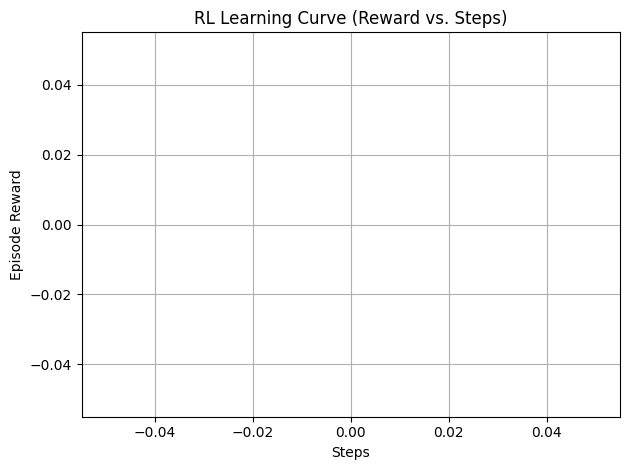

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(log_dir + "monitor.csv", skiprows=1)
plt.plot(df["l"].cumsum(), df["r"])  # "l" = episode length, "r" = episode reward
plt.xlabel("Steps")
plt.ylabel("Episode Reward")
plt.title("RL Learning Curve (Reward vs. Steps)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [46]:
from stable_baselines3.common.monitor import Monitor

log_dir = "./logs/"
os.makedirs(log_dir, exist_ok=True)
env = Monitor(env, filename=log_dir + "monitor.csv")

vec_env = DummyVecEnv([lambda: env])  # wrap monitored env


In [47]:
model = PPO("MlpPolicy", vec_env, verbose=1)


Using cuda device


c:\Users\Mimja\AppData\Local\Programs\Python\Python311\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning:

You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.



In [48]:
model.learn(total_timesteps=10000)


Step 100: Unassigned: 503, Avg Faculty Load: 0.4h
Step 200: Unassigned: 487, Avg Faculty Load: 0.8h
Step 300: Unassigned: 474, Avg Faculty Load: 1.2h
Step 400: Unassigned: 465, Avg Faculty Load: 1.5h
Step 500: Unassigned: 455, Avg Faculty Load: 1.7h
Step 600: Unassigned: 442, Avg Faculty Load: 2.1h
Step 700: Unassigned: 430, Avg Faculty Load: 2.5h
Step 800: Unassigned: 417, Avg Faculty Load: 2.8h
Step 900: Unassigned: 411, Avg Faculty Load: 3.0h
Step 1000: Unassigned: 402, Avg Faculty Load: 3.2h
Step 1100: Unassigned: 394, Avg Faculty Load: 3.5h
Step 1200: Unassigned: 386, Avg Faculty Load: 3.7h
Step 1300: Unassigned: 381, Avg Faculty Load: 3.8h
Step 1400: Unassigned: 367, Avg Faculty Load: 4.3h
Step 1500: Unassigned: 360, Avg Faculty Load: 4.5h
Step 1600: Unassigned: 356, Avg Faculty Load: 4.6h
Step 1700: Unassigned: 349, Avg Faculty Load: 4.8h
Step 1800: Unassigned: 345, Avg Faculty Load: 4.9h
Step 1900: Unassigned: 337, Avg Faculty Load: 5.1h
Step 2000: Unassigned: 333, Avg Faculty 

In [49]:
import pandas as pd

df = pd.read_csv("./logs/monitor.csv", skiprows=1)
print(df.head())


Empty DataFrame
Columns: [r, l, t]
Index: []


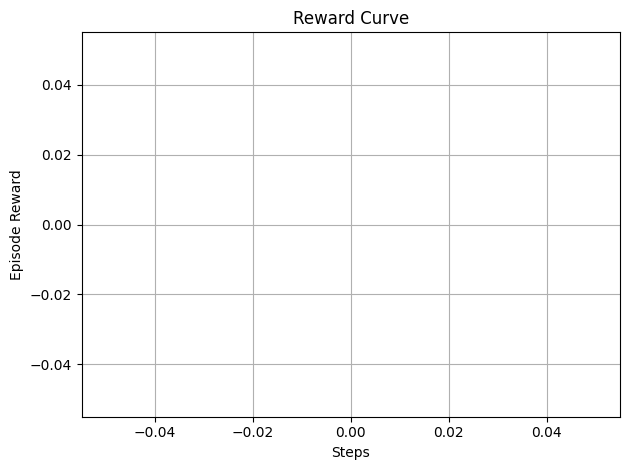

In [50]:
import matplotlib.pyplot as plt

plt.plot(df["l"].cumsum(), df["r"])  # cumulative steps vs reward
plt.xlabel("Steps")
plt.ylabel("Episode Reward")
plt.title("Reward Curve")
plt.grid(True)
plt.tight_layout()
plt.show()
